In [16]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from utilsforecast.plotting import plot_series

In [17]:
# Load Full Paths
path = r"S:\WP Personnel\A - Workforce\Data science student\Desys Corner"
# Load CSVs
leavers = pd.read_csv(
    f"{path}\\NHS_Leavers_Detail.csv", parse_dates=["Termination Date"], dayfirst=True
)
hires = pd.read_csv(
    f"{path}\\Hires_Detail_New.csv", parse_dates=["Latest Start Date"], dayfirst=True
)
sickness = pd.read_csv(
    f"{path}\\Sickness_Percentage_New.csv", parse_dates=["Month"], dayfirst=True
)

C:\Users\Destinee.HassanBien\AppData\Local\Temp\ipykernel_14936\3822221294.py:10: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  sickness = pd.read_csv(


In [18]:
# Prepare Leavers
leavers.dropna(subset=["Termination Date"], inplace=True)
leavers["ds"] = leavers["Termination Date"].dt.to_period("M").dt.to_timestamp()
leavers["Org"] = leavers["Organisation"].str.replace(r"\s+", "", regex=True)
leavers["Service"] = leavers["Service group"].str.replace(r"\s+", "", regex=True)
leavers["Staff"] = leavers["Staff Group"].str.replace(r"\s+", "", regex=True)
leavers["Dep"] = leavers["Department"].str.replace(r"\s+", "", regex=True)
leavers["unique_id"] = (
    leavers["Org"]
    + "_"
    + leavers["Service"]
    + "_"
    + leavers["Staff"]
    + "_"
    + leavers["Dep"]
)

leavers_monthly = (
    leavers.groupby(["unique_id", "ds"]).size().reset_index(name="leavers_count")
)

# Prepare Hires
hires.dropna(subset=["Latest Start Date"], inplace=True)
hires["ds"] = hires["Latest Start Date"].dt.to_period("M").dt.to_timestamp()
hires["Org"] = hires["Organisation"].str.replace(r"\s+", "", regex=True)
hires["Service"] = hires["Service group"].str.replace(r"\s+", "", regex=True)
hires["Staff"] = hires["Staff Group"].str.replace(r"\s+", "", regex=True)
hires["Dep"] = hires["Department"].str.replace(r"\s+", "", regex=True)
hires["unique_id"] = (
    hires["Org"] + "_" + hires["Service"] + "_" + hires["Staff"] + "_" + hires["Dep"]
)

hires_monthly = (
    hires.groupby(["unique_id", "ds"]).size().reset_index(name="hires_count")
)

# Prepare Sickness
sickness.dropna(subset=["Month"], inplace=True)
sickness["Month"] = pd.to_datetime(sickness["Month"], errors="coerce")
sickness["ds"] = sickness["Month"].dt.to_period("M").dt.to_timestamp()
sickness["Org"] = sickness["Organisation"].str.replace(r"\s+", "", regex=True)
sickness["Service"] = sickness["Service Group"].str.replace(r"\s+", "", regex=True)
sickness["Staff"] = sickness["Staff Group"].str.replace(r"\s+", "", regex=True)
sickness["Dep"] = sickness["Department"].str.replace(r"\s+", "", regex=True)
sickness["unique_id"] = (
    sickness["Org"]
    + "_"
    + sickness["Service"]
    + "_"
    + sickness["Staff"]
    + "_"
    + sickness["Dep"]
)

sickness_monthly = (
    sickness.groupby(["unique_id", "ds"])
    .agg({"Abs (FTE)": "sum", "Avail (FTE)": "sum"})
    .reset_index()
)

sickness_monthly["sickness_pct"] = np.where(
    (sickness_monthly["Avail (FTE)"] > 0) & (sickness_monthly["Abs (FTE)"].notna()),
    (sickness_monthly["Abs (FTE)"] / sickness_monthly["Avail (FTE)"]) * 100,
    np.nan,
)

sickness_monthly["sickness_pct"] = sickness_monthly["sickness_pct"].round(2)

C:\Users\Destinee.HassanBien\AppData\Local\Temp\ipykernel_14936\2246307904.py:39: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  sickness["Month"] = pd.to_datetime(sickness["Month"], errors="coerce")


In [19]:
# Merge all monthy data
df_combined = leavers_monthly.merge(
    hires_monthly, on=["unique_id", "ds"], how="outer"
).merge(
    sickness_monthly[["unique_id", "ds", "sickness_pct"]],
    on=["unique_id", "ds"],
    how="outer",
)

#  Fill NaNs with 0 where appropriate
df_combined["leavers_count"] = df_combined["leavers_count"].fillna(0)
df_combined["hires_count"] = df_combined["hires_count"].fillna(0)
df_combined["sickness_pct"] = df_combined["sickness_pct"].fillna(method="ffill")

df_combined.to_csv("df_combined.csv", index=False)

C:\Users\Destinee.HassanBien\AppData\Local\Temp\ipykernel_14936\3555737271.py:13: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_combined["sickness_pct"] = df_combined["sickness_pct"].fillna(method="ffill")
C:\Users\Destinee.HassanBien\AppData\Local\Temp\ipykernel_14936\3555737271.py:13: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_combined["sickness_pct"] = df_combined["sickness_pct"].fillna(method="ffill")


In [20]:
# Plot Time Series for a Sample group
example_uid = df_combined["unique_id"].dropna().unique()[0]
sample_data = df_combined[df_combined["unique_id"] == example_uid].sort_values("ds")

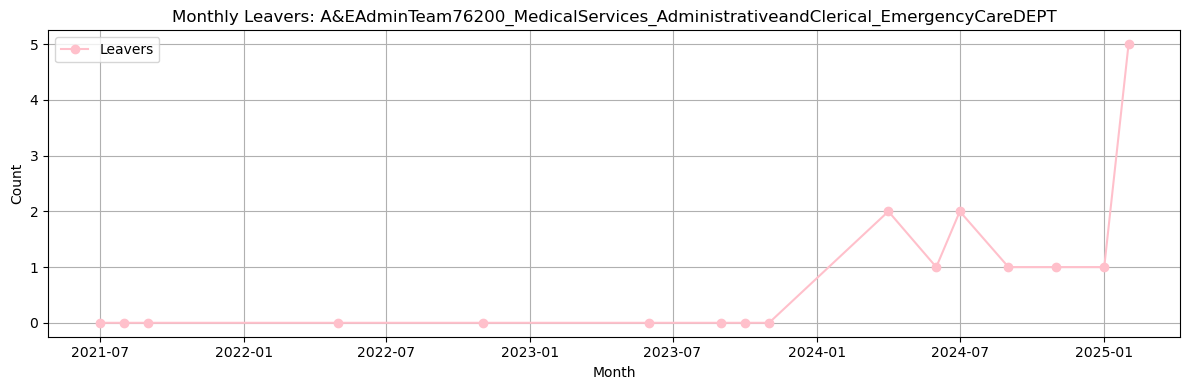

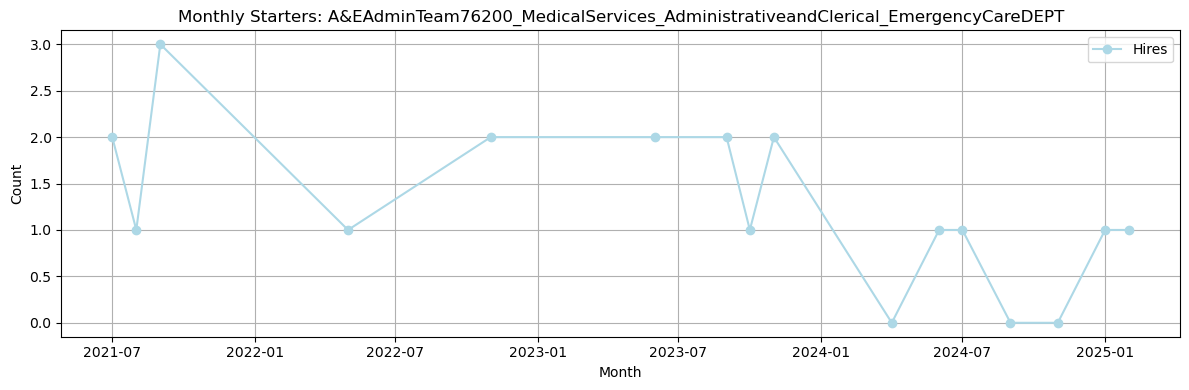

<function matplotlib.pyplot.show(close=None, block=None)>

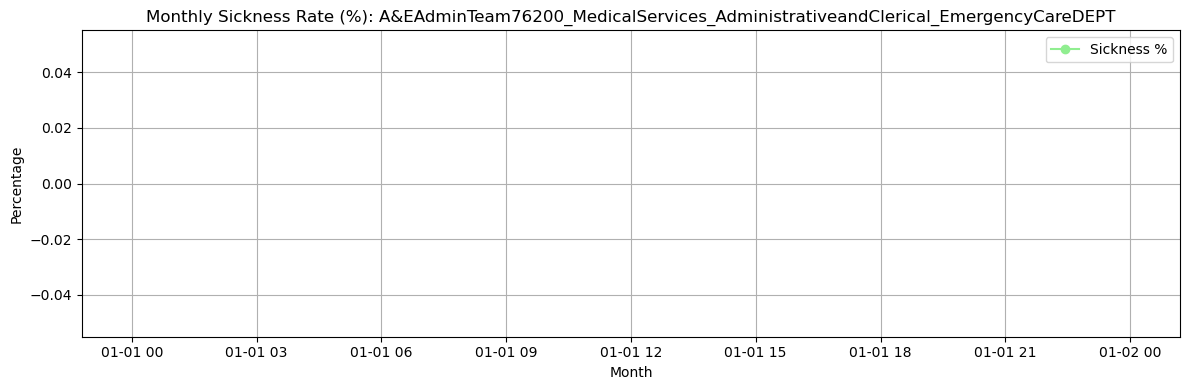

In [21]:
# Plot Leavers
plt.figure(figsize=(12, 4))
plt.plot(
    sample_data["ds"],
    sample_data["leavers_count"],
    marker="o",
    color="pink",
    label="Leavers",
)
plt.title(f"Monthly Leavers: {example_uid}")
plt.xlabel("Month")
plt.ylabel("Count")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig("monthly_leavers.png")
plt.show()

# Plot Hires
plt.figure(figsize=(12, 4))
plt.plot(
    sample_data["ds"],
    sample_data["hires_count"],
    marker="o",
    color="lightblue",
    label="Hires",
)
plt.title(f"Monthly Starters: {example_uid}")
plt.xlabel("Month")
plt.ylabel("Count")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig("monthly_starters.png")
plt.show()

# Plot Sickness
plt.figure(figsize=(12, 4))
plt.plot(
    sample_data["ds"],
    sample_data["sickness_pct"],
    marker="o",
    color="lightgreen",
    label="Sickness %",
)
plt.title(f"Monthly Sickness Rate (%): {example_uid}")
plt.xlabel("Month")
plt.ylabel("Percentage")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show

In [15]:
# Tracks workforce dynamics overtime (leavers and starters)
# It should provide absence trends through sickness percentage
# Uses unique_ids to disaggregate data by Org, Service, Staff group and Deparmtnet